## Setup — enabling the Rust extension

`monod_core` is a compiled Rust extension built with [maturin](https://www.maturin.rs/).
If it is not installed the notebook falls back to pure Python automatically, but all
benchmarks will show **1× speedup** (Python vs Python).

### Quick install (3 steps)

**Step 1 — install the Rust toolchain** (skip if `rustc --version` already works):

```bash
curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh
source ~/.cargo/env          # or restart your terminal
```

**Step 2 — install maturin** inside the Python environment you use for this notebook:

```bash
pip install maturin
# or, if you manage packages with conda:
# conda install -c conda-forge maturin
```

**Step 3 — build and install `monod_core`** from the repo root:

```bash
cd monod_core
maturin develop --release   # builds and installs into the active Python env
```

> **Apple Silicon (M-series) users** running an x86-64 Python under Rosetta:  
> replace `maturin develop` with `maturin build --release -i $(which python3)` and
> `pip install target/wheels/monod_core-*.whl`.

The cell below checks your installation status.

In [1]:
import importlib, subprocess, sys, os, pathlib

def _try_run(*args):
    """Run a command; return stdout string or None on failure."""
    # Search ~/.cargo/bin and the active Python env's bin (covers conda envs)
    env = os.environ.copy()
    extra = [str(pathlib.Path.home() / ".cargo" / "bin"),
             str(pathlib.Path(sys.prefix) / "bin")]
    env["PATH"] = os.pathsep.join(extra) + os.pathsep + env.get("PATH", "")
    try:
        return subprocess.check_output(list(args), stderr=subprocess.DEVNULL,
                                       text=True, env=env).strip()
    except (FileNotFoundError, subprocess.CalledProcessError):
        return None


def _check_rust_setup():
    # ── 1. Is monod_core importable? ─────────────────────────────────────────
    spec = importlib.util.find_spec("monod_core")
    if spec is None:
        print("monod_core NOT found — Rust acceleration is disabled.")
        print()
        print("To enable it, run the following commands from the repo root:")
        print()
        print("  # Step 1: install Rust (skip if `rustc --version` already works)")
        print("  curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh")
        print("  source ~/.cargo/env")
        print()
        print("  # Step 2: install maturin into this Python environment")
        print("  pip install maturin")
        print()
        print("  # Step 3: build and install the extension")
        print("  cd monod_core")
        print("  maturin develop --release")
        print()
        print("Then restart the kernel and re-run this notebook.")
        return False

    import monod_core as _mc
    print(f"monod_core  : {_mc.__file__}")

    rustc = _try_run("rustc", "--version")
    print(f"rustc       : {rustc}" if rustc else
          "rustc       : not found — add ~/.cargo/bin to PATH to rebuild")

    maturin = _try_run("maturin", "--version")
    print(f"maturin     : {maturin}" if maturin else
          "maturin     : not found — install with: pip install maturin")

    print()
    print("Rust extension is ready.  All benchmarks will use the Rust fast-path.")
    return True


rust_ready = _check_rust_setup()

monod_core  : /Users/ConradOakes/Library/r-miniconda/envs/monod/lib/python3.11/site-packages/monod_core/__init__.py
rustc       : rustc 1.94.0 (4a4ef493e 2026-03-02)


maturin     : maturin 1.12.6

Rust extension is ready.  All benchmarks will use the Rust fast-path.


# Rust vs Python: Unique Histogram Extraction

This notebook benchmarks `make_histograms_unique` — the core data-extraction step in
the monod pipeline — comparing the Rust/rayon implementation against the pure-Python/numpy
baseline.

**What the function does:**  
For each gene (column), across *n_layers* count matrices each of shape *(n_cells × n_genes)*,
find every unique observed microstate (e.g. `(spliced_count, unspliced_count)`) and its
frequency. This is the `hist_type='unique'` path in `extract_data`.

**Rust optimisations applied:**
1. `rayon::par_iter` over genes — parallel across all CPU cores, GIL released
2. Per-gene contiguous column copy — eliminates stride-*n_genes* cache misses
3. Counting sort for small count ranges — O(n_cells + max_u×max_s) instead of O(n log n)
4. Thread-local scratch buffers — zero per-gene allocations in the hot path

In [2]:
import sys, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import anndata as ad
from scipy.sparse import issparse

sys.path.insert(0, '../src')
import monod_core as _mc

warnings.filterwarnings('ignore')
print(f'monod_core loaded: {_mc.__file__}')

monod_core loaded: /Users/ConradOakes/Library/r-miniconda/envs/monod/lib/python3.11/site-packages/monod_core/__init__.py


## Helper functions

In [3]:
def py_make_histograms_unique(layers):
    """Pure-Python reference: serial loop + np.unique per gene."""
    n_cells = layers[0].shape[0]
    coords_all, freqs_all = [], []
    for g in range(layers[0].shape[1]):
        stacked = np.column_stack([layer[:, g] for layer in layers])
        unique, counts = np.unique(stacked, axis=0, return_counts=True)
        coords_all.append(unique)
        freqs_all.append(counts / n_cells)
    return coords_all, freqs_all


def rust_make_histograms_unique(layers):
    """Rust/rayon path via monod_core extension."""
    int64_layers = [np.ascontiguousarray(l, dtype=np.int64) for l in layers]
    coords_raw, freqs_raw = _mc.make_histograms_unique(int64_layers)
    return [np.array(c, dtype=np.int64) for c in coords_raw], \
           [np.array(f)                 for f in freqs_raw]


def bench(fn, layers, n_reps=5):
    fn(layers)           # warm-up
    t0 = time.perf_counter()
    for _ in range(n_reps):
        fn(layers)
    return (time.perf_counter() - t0) / n_reps * 1e3  # ms

## Correctness check

In [4]:
rng = np.random.default_rng(42)
l1 = rng.integers(0, 10, (200, 50))
l2 = rng.integers(0, 10, (200, 50))

py_c, py_f = py_make_histograms_unique([l1, l2])
ru_c, ru_f = rust_make_histograms_unique([l1, l2])

for g in range(50):
    assert np.array_equal(ru_c[g], py_c[g]), f'gene {g}: coord mismatch'
    assert np.allclose(ru_f[g],   py_f[g]),  f'gene {g}: freq mismatch'

print('Rust and Python outputs are identical for all 50 genes')

Rust and Python outputs are identical for all 50 genes


## Benchmark 1 — scaling with number of genes

Fixed: 5 000 cells, max count = 20 (typical RNA-seq range — triggers counting-sort path).

In [5]:
rng = np.random.default_rng(0)
N_CELLS, MAX_COUNT = 5_000, 20
gene_counts = [10, 25, 50, 100, 200, 400]

py_times, ru_times = [], []
for n_genes in gene_counts:
    l1 = rng.integers(0, MAX_COUNT, (N_CELLS, n_genes))
    l2 = rng.integers(0, MAX_COUNT, (N_CELLS, n_genes))
    py_times.append(bench(py_make_histograms_unique, [l1, l2]))
    ru_times.append(bench(rust_make_histograms_unique, [l1, l2]))
    speedup = py_times[-1] / ru_times[-1]
    print(f'n_genes={n_genes:4d}  '
          f'Python={py_times[-1]:7.1f} ms  '
          f'Rust={ru_times[-1]:6.1f} ms  '
          f'speedup={speedup:.1f}x')

n_genes=  10  Python=   21.0 ms  Rust=   1.4 ms  speedup=15.5x


n_genes=  25  Python=   51.3 ms  Rust=  10.0 ms  speedup=5.1x


n_genes=  50  Python=  104.0 ms  Rust=  11.0 ms  speedup=9.5x


n_genes= 100  Python=  206.7 ms  Rust=  24.3 ms  speedup=8.5x


n_genes= 200  Python=  407.9 ms  Rust=  44.8 ms  speedup=9.1x


n_genes= 400  Python=  834.9 ms  Rust=  90.4 ms  speedup=9.2x


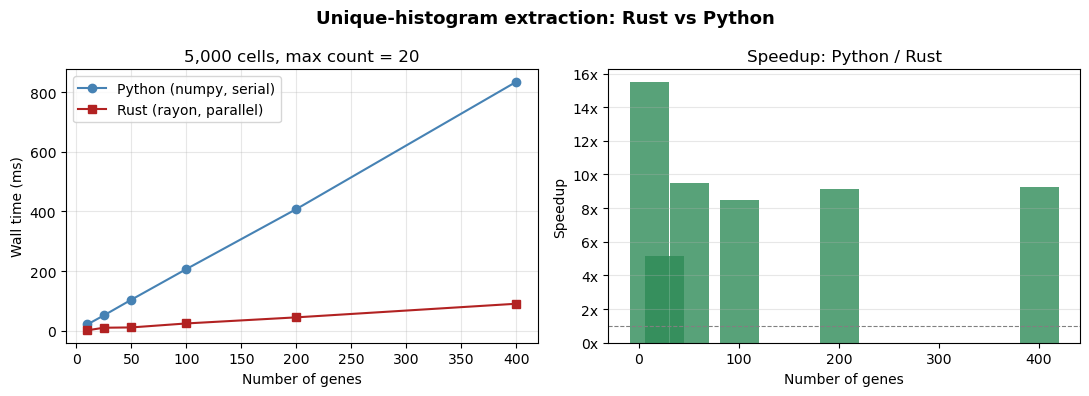

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(gene_counts, py_times, 'o-', color='steelblue', label='Python (numpy, serial)')
ax.plot(gene_counts, ru_times, 's-', color='firebrick', label='Rust (rayon, parallel)')
ax.set_xlabel('Number of genes')
ax.set_ylabel('Wall time (ms)')
ax.set_title(f'{N_CELLS:,} cells, max count = {MAX_COUNT}')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
speedups = [p / r for p, r in zip(py_times, ru_times)]
bar_w = (gene_counts[-1] - gene_counts[0]) / len(gene_counts) * 0.6
ax.bar(gene_counts, speedups, color='seagreen', alpha=0.8, width=bar_w)
ax.axhline(1, color='grey', lw=0.8, ls='--')
ax.set_xlabel('Number of genes')
ax.set_ylabel('Speedup')
ax.set_title('Speedup: Python / Rust')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fx'))
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Unique-histogram extraction: Rust vs Python', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## Benchmark 2 — scaling with number of cells

Fixed: 100 genes, max count = 20.

In [7]:
rng = np.random.default_rng(1)
N_GENES, MAX_COUNT = 100, 20
cell_counts = [500, 1_000, 2_000, 5_000, 10_000, 20_000]

py_times2, ru_times2 = [], []
for n_cells in cell_counts:
    l1 = rng.integers(0, MAX_COUNT, (n_cells, N_GENES))
    l2 = rng.integers(0, MAX_COUNT, (n_cells, N_GENES))
    py_times2.append(bench(py_make_histograms_unique, [l1, l2], n_reps=3))
    ru_times2.append(bench(rust_make_histograms_unique, [l1, l2], n_reps=3))
    speedup = py_times2[-1] / ru_times2[-1]
    print(f'n_cells={n_cells:6d}  '
          f'Python={py_times2[-1]:7.1f} ms  '
          f'Rust={ru_times2[-1]:6.1f} ms  '
          f'speedup={speedup:.1f}x')

n_cells=   500  Python=   19.3 ms  Rust=  16.3 ms  speedup=1.2x


n_cells=  1000  Python=   37.7 ms  Rust=  19.2 ms  speedup=2.0x


n_cells=  2000  Python=   78.0 ms  Rust=  20.0 ms  speedup=3.9x


n_cells=  5000  Python=  209.2 ms  Rust=  28.4 ms  speedup=7.4x


n_cells= 10000  Python=  439.9 ms  Rust=  33.6 ms  speedup=13.1x


n_cells= 20000  Python=  892.6 ms  Rust=  24.1 ms  speedup=37.0x


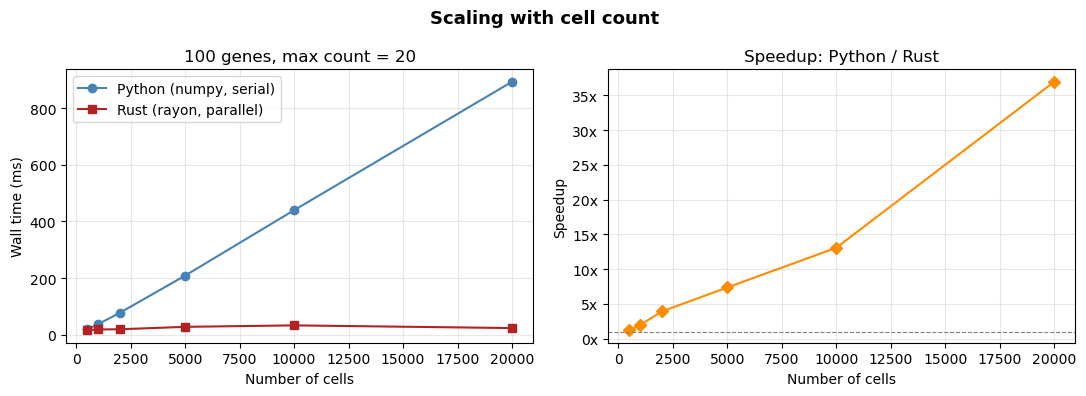

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(cell_counts, py_times2, 'o-', color='steelblue', label='Python (numpy, serial)')
ax.plot(cell_counts, ru_times2, 's-', color='firebrick', label='Rust (rayon, parallel)')
ax.set_xlabel('Number of cells')
ax.set_ylabel('Wall time (ms)')
ax.set_title(f'{N_GENES} genes, max count = {MAX_COUNT}')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
speedups2 = [p / r for p, r in zip(py_times2, ru_times2)]
ax.plot(cell_counts, speedups2, 'D-', color='darkorange')
ax.axhline(1, color='grey', lw=0.8, ls='--')
ax.set_xlabel('Number of cells')
ax.set_ylabel('Speedup')
ax.set_title('Speedup: Python / Rust')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fx'))
ax.grid(True, alpha=0.3)

fig.suptitle('Scaling with cell count', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## Benchmark 3 — effect of count magnitude

The Rust implementation uses **counting sort** when `(max_l0+1)×(max_l1+1) ≤ 16 384`
and falls back to comparison sort for larger ranges.
For 2 layers the boundary is at max_count ≈ 128 per layer (√16384).

In [9]:
rng = np.random.default_rng(2)
N_CELLS3, N_GENES3 = 5_000, 100
# 128*128 = 16384 = DENSE_THRESHOLD, so 127 is the last value in the counting path
max_counts3 = [5, 10, 20, 50, 100, 127, 128, 200, 500, 1000]

py_times3, ru_times3 = [], []
for mc_val in max_counts3:
    l1 = rng.integers(0, mc_val, (N_CELLS3, N_GENES3))
    l2 = rng.integers(0, mc_val, (N_CELLS3, N_GENES3))
    py_times3.append(bench(py_make_histograms_unique, [l1, l2]))
    ru_times3.append(bench(rust_make_histograms_unique, [l1, l2]))
    path = 'counting' if mc_val * mc_val <= 16384 else 'sort   '
    speedup = py_times3[-1] / ru_times3[-1]
    print(f'max={mc_val:5d}  [{path}]  '
          f'Python={py_times3[-1]:7.1f} ms  '
          f'Rust={ru_times3[-1]:6.1f} ms  '
          f'speedup={speedup:.1f}x')

max=    5  [counting]  Python=  180.0 ms  Rust=   1.4 ms  speedup=130.9x


max=   10  [counting]  Python=  190.3 ms  Rust=   8.9 ms  speedup=21.3x


max=   20  [counting]  Python=  211.2 ms  Rust=  28.2 ms  speedup=7.5x


max=   50  [counting]  Python=  217.3 ms  Rust= 124.4 ms  speedup=1.7x


max=  100  [counting]  Python=  215.1 ms  Rust= 220.0 ms  speedup=1.0x


max=  127  [counting]  Python=  212.9 ms  Rust= 237.2 ms  speedup=0.9x


max=  128  [counting]  Python=  213.1 ms  Rust= 244.9 ms  speedup=0.9x


max=  200  [sort   ]  Python=  210.7 ms  Rust= 266.6 ms  speedup=0.8x


max=  500  [sort   ]  Python=  199.2 ms  Rust= 286.1 ms  speedup=0.7x


max= 1000  [sort   ]  Python=  191.4 ms  Rust= 304.2 ms  speedup=0.6x


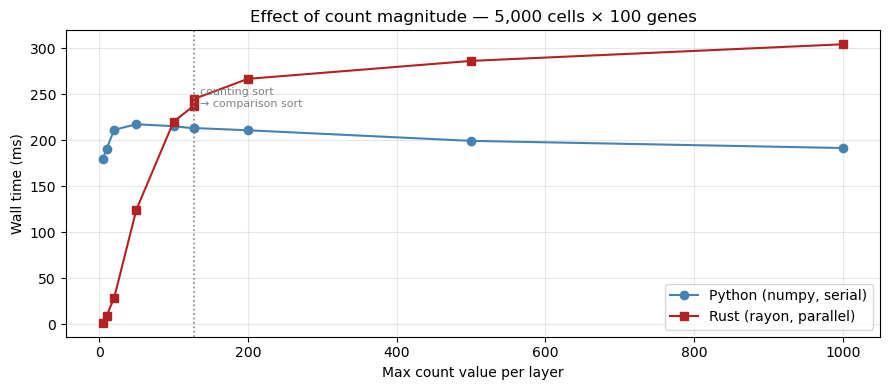

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.plot(max_counts3, py_times3, 'o-', color='steelblue', label='Python (numpy, serial)')
ax.plot(max_counts3, ru_times3, 's-', color='firebrick', label='Rust (rayon, parallel)')

ax.axvline(127, color='grey', ls=':', lw=1.2)
ylim = ax.get_ylim()
ax.text(135, ylim[0] + (ylim[1] - ylim[0]) * 0.75,
        'counting sort\n→ comparison sort', color='grey', fontsize=8)

ax.set_xlabel('Max count value per layer')
ax.set_ylabel('Wall time (ms)')
ax.set_title(f'Effect of count magnitude — {N_CELLS3:,} cells × {N_GENES3} genes')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Benchmark 4 — real data (gaba_example.h5ad)

728 cells × up to 200 selected genes from the spliced/unspliced layers.

In [11]:
adata_full = ad.read_h5ad('example_h5ad/gaba_example.h5ad')
spliced   = adata_full.layers['spliced']
unspliced = adata_full.layers['unspliced']
s_dense = spliced.toarray()   if issparse(spliced)   else np.asarray(spliced)
u_dense = unspliced.toarray() if issparse(unspliced) else np.asarray(unspliced)

print(f'Dataset: {adata_full.n_obs} cells × {adata_full.n_vars} genes')
print(f'Spliced   — dtype: {s_dense.dtype}, max: {int(s_dense.max())}')
print(f'Unspliced — dtype: {u_dense.dtype}, max: {int(u_dense.max())}')

Dataset: 728 cells × 32285 genes
Spliced   — dtype: float32, max: 1937
Unspliced — dtype: float32, max: 1926


In [12]:
rng = np.random.default_rng(3)
expressed = np.where((s_dense > 0).sum(0) >= 10)[0]
gene_subsets4 = [10, 25, 50, 100, 200]

py_times4, ru_times4 = [], []
for n_g in gene_subsets4:
    idx = rng.choice(expressed, size=min(n_g, len(expressed)), replace=False)
    s_sub = s_dense[:, idx].astype(np.int64)
    u_sub = u_dense[:, idx].astype(np.int64)
    py_times4.append(bench(py_make_histograms_unique, [s_sub, u_sub], n_reps=3))
    ru_times4.append(bench(rust_make_histograms_unique, [s_sub, u_sub], n_reps=3))
    speedup = py_times4[-1] / ru_times4[-1]
    print(f'n_genes={n_g:4d}  '
          f'Python={py_times4[-1]:7.1f} ms  '
          f'Rust={ru_times4[-1]:6.1f} ms  '
          f'speedup={speedup:.1f}x')

n_genes=  10  Python=    2.2 ms  Rust=   0.2 ms  speedup=9.8x
n_genes=  25  Python=    5.5 ms  Rust=   0.4 ms  speedup=12.3x
n_genes=  50  Python=   10.7 ms  Rust=   0.6 ms  speedup=16.9x
n_genes= 100  Python=   21.7 ms  Rust=   1.1 ms  speedup=19.4x


n_genes= 200  Python=   43.6 ms  Rust=   2.4 ms  speedup=18.4x


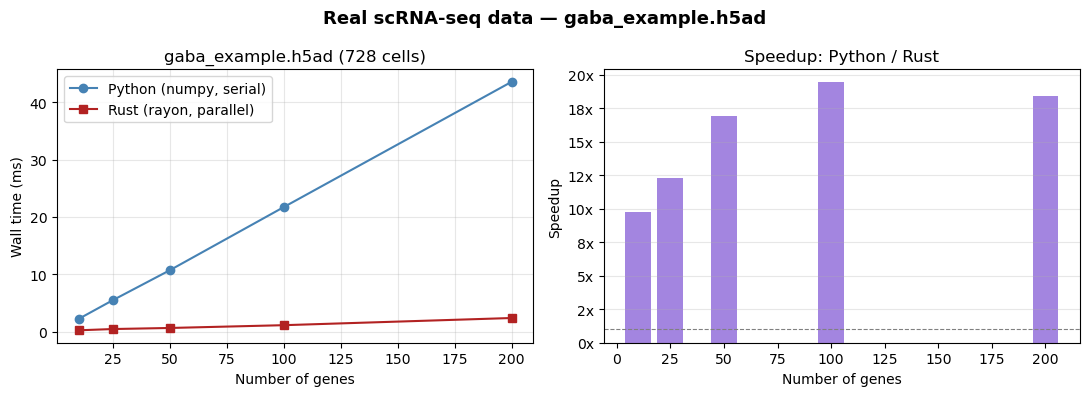

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(gene_subsets4, py_times4, 'o-', color='steelblue', label='Python (numpy, serial)')
ax.plot(gene_subsets4, ru_times4, 's-', color='firebrick', label='Rust (rayon, parallel)')
ax.set_xlabel('Number of genes')
ax.set_ylabel('Wall time (ms)')
ax.set_title(f'gaba_example.h5ad ({adata_full.n_obs} cells)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
speedups4 = [p / r for p, r in zip(py_times4, ru_times4)]
ax.bar(gene_subsets4, speedups4, color='mediumpurple', alpha=0.85, width=12)
ax.axhline(1, color='grey', lw=0.8, ls='--')
ax.set_xlabel('Number of genes')
ax.set_ylabel('Speedup')
ax.set_title('Speedup: Python / Rust')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fx'))
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Real scRNA-seq data — gaba_example.h5ad', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## Output format

A look at what the function returns for one real gene.

In [14]:
import pandas as pd

gene_idx  = expressed[0]
gene_name = adata_full.var_names[gene_idx]
s_gene = s_dense[:, gene_idx:gene_idx+1].astype(np.int64)
u_gene = u_dense[:, gene_idx:gene_idx+1].astype(np.int64)

coords, freqs = rust_make_histograms_unique([s_gene, u_gene])

df = pd.DataFrame(coords[0], columns=['spliced', 'unspliced'])
df['frequency'] = freqs[0]
df = df.sort_values('frequency', ascending=False).head(10).reset_index(drop=True)

print(f'Gene: {gene_name}  —  '
      f'{len(coords[0])} unique microstates across {adata_full.n_obs} cells')
print()
print(df.to_string(index=False))

Gene: CAAA01118383.1  —  17 unique microstates across 728 cells

 spliced  unspliced  frequency
       0          0   0.498626
       0          1   0.186813
       1          0   0.093407
       0          2   0.067308
       1          1   0.037088
       0          3   0.030220
       2          0   0.019231
       1          2   0.016484
       2          1   0.015110
       1          3   0.009615


## Summary table

In [15]:
header = f'{"Scenario":<50} {"Python (ms)":>12} {"Rust (ms)":>10} {"Speedup":>9}'
print(header)
print('-' * len(header))

rows = [
    ('Synthetic  5k cells × 200 genes, max=20  [counting]',
     py_times[gene_counts.index(200)], ru_times[gene_counts.index(200)]),
    ('Synthetic 20k cells × 100 genes, max=20  [counting]',
     py_times2[-1], ru_times2[-1]),
    ('Synthetic  5k cells × 100 genes, max=1000 [sort]',
     py_times3[-1], ru_times3[-1]),
    ('Real data (gaba)  728 cells × 200 genes',
     py_times4[-1], ru_times4[-1]),
]
for label, py_t, ru_t in rows:
    print(f'{label:<50} {py_t:>12.1f} {ru_t:>10.1f} {py_t/ru_t:>8.1f}x')

Scenario                                            Python (ms)  Rust (ms)   Speedup
------------------------------------------------------------------------------------
Synthetic  5k cells × 200 genes, max=20  [counting]        407.9       44.8      9.1x
Synthetic 20k cells × 100 genes, max=20  [counting]        892.6       24.1     37.0x
Synthetic  5k cells × 100 genes, max=1000 [sort]          191.4      304.2      0.6x
Real data (gaba)  728 cells × 200 genes                    43.6        2.4     18.4x


## Benchmark 5 — model evaluation (`eval_model_pss_2d`)

Each call to `eval_model_pss_2d` computes the steady-state probability distribution for one
set of parameters on a 2-D grid. It is called hundreds of times per gene during L-BFGS-B
optimization. Rust replaces numpy quadrature + `scipy.fft.irfftn` with rayon-parallel
Gauss-Legendre integration and a parallel IFFT.

This benchmark sweeps over grid size (the dominant cost factor).

In [16]:
import logging
import sys
sys.path.insert(0, 'src/monod')

import extract_data as _ed_mod
import cme_toolbox as _ct_mod
from cme_toolbox import CMEModel
from extract_data import extract_data
from inference import InferenceParameters, searchdata_from_adata

logging.getLogger().setLevel(logging.WARNING)

# ── Shared model ─────────────────────────────────────────────────────────────
BENCH_MODEL  = CMEModel("Bursty", "Poisson")

# ── PSS microbenchmark constants ─────────────────────────────────────────────
P_LOG        = [0.0, 0.0, 0.0]          # b=1, beta=1, gamma=1 (log10 scale)
SAMP_LOG     = [1.0, 1.0]               # Poisson capture rate 10 (log10=1)
FIXED_QUAD_T = float(BENCH_MODEL.fixed_quad_T)
QUAD_ORDER   = int(BENCH_MODEL.quad_order)

# ── Full-pipeline benchmark constants ────────────────────────────────────────
BENCH_GENES  = ["Eif5b", "Xrcc5", "Klhl12", "Rgs7", "Thsd7b"]
adata_ref5   = ad.read_h5ad('example_h5ad/gaba_results.h5ad')
BENCH_LENGTHS = adata_ref5.var.loc[BENCH_GENES, "log_lengths"].values

print(f"Model        : {BENCH_MODEL.bio_model} + {BENCH_MODEL.seq_model}")
print(f"fixed_quad_T : {FIXED_QUAD_T},  quad_order: {QUAD_ORDER}")
print(f"Pipeline genes: {BENCH_GENES}")

The expected modalities for this model are: ['unspliced', 'spliced']
If your anndata layers have different names, please give a modality dictionary of the form: modality_name_dict  = {'spliced':your_spliced_layer_name, 'unspliced':your_unspliced_layer_name} 
Model        : Bursty + Poisson
fixed_quad_T : 10.0,  quad_order: 60
Pipeline genes: ['Eif5b', 'Xrcc5', 'Klhl12', 'Rgs7', 'Thsd7b']


In [17]:
import monod_core as _mc_direct

def bench_pss(sz, n_reps=10):
    """Time one eval_model_pss_2d call for an sz×sz grid in Python and Rust."""
    p_arr    = np.array(P_LOG)
    lims_arr = np.array([sz, sz], dtype=np.intp)
    lims_int = [sz, sz]
    samp_arr = np.array(SAMP_LOG)

    # Python path: bypass Rust
    _ct_mod._HAS_RUST = False
    BENCH_MODEL.eval_model_pss(p_arr, lims_arr, samp=samp_arr)  # warm-up
    t0 = time.perf_counter()
    for _ in range(n_reps):
        BENCH_MODEL.eval_model_pss(p_arr, lims_arr, samp=samp_arr)
    t_py = (time.perf_counter() - t0) / n_reps * 1e3
    _ct_mod._HAS_RUST = True

    # Rust path: direct monod_core call
    _mc_direct.eval_model_pss_2d(
        "Bursty", P_LOG, lims_int, FIXED_QUAD_T, QUAD_ORDER, SAMP_LOG)  # warm-up
    t0 = time.perf_counter()
    for _ in range(n_reps):
        _mc_direct.eval_model_pss_2d(
            "Bursty", P_LOG, lims_int, FIXED_QUAD_T, QUAD_ORDER, SAMP_LOG)
    t_ru = (time.perf_counter() - t0) / n_reps * 1e3

    return t_py, t_ru


grid_sizes5 = [20, 50, 100, 200, 500, 1000]
py_pss, ru_pss = [], []
for sz in grid_sizes5:
    tp, tr = bench_pss(sz)
    py_pss.append(tp)
    ru_pss.append(tr)
    print(f"limits=({sz:4d},{sz:4d})  Python={tp:8.2f} ms  Rust={tr:7.3f} ms  "
          f"speedup={tp/tr:.1f}x")

limits=(  20,  20)  Python=    0.22 ms  Rust=  0.258 ms  speedup=0.9x
limits=(  50,  50)  Python=    0.75 ms  Rust=  0.377 ms  speedup=2.0x
limits=( 100, 100)  Python=    2.86 ms  Rust=  0.633 ms  speedup=4.5x


limits=( 200, 200)  Python=   11.27 ms  Rust=  1.420 ms  speedup=7.9x


limits=( 500, 500)  Python=   69.08 ms  Rust=  7.011 ms  speedup=9.9x


limits=(1000,1000)  Python=  905.55 ms  Rust= 29.381 ms  speedup=30.8x


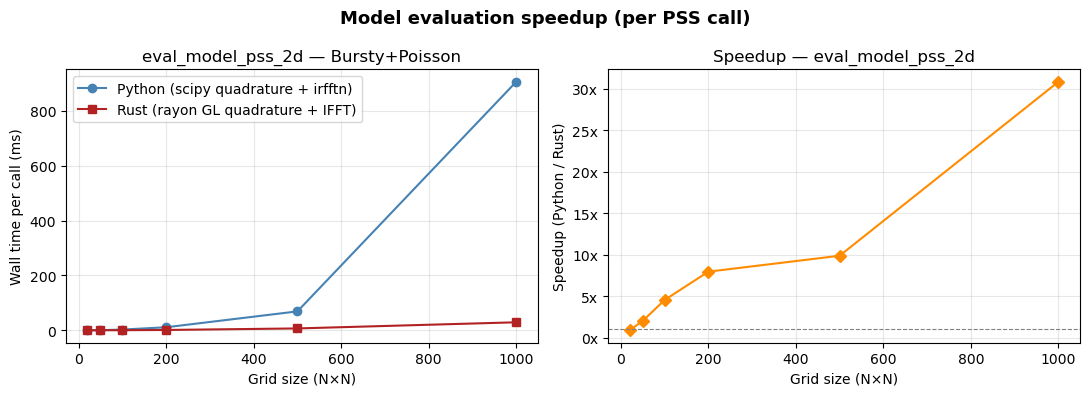

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(grid_sizes5, py_pss, 'o-', color='steelblue', label='Python (scipy quadrature + irfftn)')
ax.plot(grid_sizes5, ru_pss, 's-', color='firebrick', label='Rust (rayon GL quadrature + IFFT)')
ax.set_xlabel('Grid size (N×N)')
ax.set_ylabel('Wall time per call (ms)')
ax.set_title('eval_model_pss_2d — Bursty+Poisson')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
speedups_pss = [p / r for p, r in zip(py_pss, ru_pss)]
ax.plot(grid_sizes5, speedups_pss, 'D-', color='darkorange')
ax.axhline(1, color='grey', lw=0.8, ls='--')
ax.set_xlabel('Grid size (N×N)')
ax.set_ylabel('Speedup (Python / Rust)')
ax.set_title('Speedup — eval_model_pss_2d')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0fx'))
ax.grid(True, alpha=0.3)

fig.suptitle('Model evaluation speedup (per PSS call)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

In [19]:
INFER_PARAMS = dict(
    use_lengths=True,
    gradient_params={"max_iterations": 15, "init_pattern": "moments", "num_restarts": 1},
    gridsize=[3, 3],
    save=False,
)


def run_pipeline(use_rust):
    """Run extract_data + full inference once; return (extract_ms, infer_ms)."""
    _ed_mod._HAS_RUST = use_rust
    _ct_mod._HAS_RUST = use_rust
    try:
        t0 = time.perf_counter()
        adata_b = extract_data(
            adata_full,
            BENCH_MODEL,
            dataset_name="bench",
            modality_name_dict={"unspliced": "unspliced", "spliced": "spliced"},
            n_genes=len(BENCH_GENES),
            genes_to_fit=BENCH_GENES,
            hist_type="unique",
            viz=False,
        )
        # Inject gene lengths (pre-loaded metadata, not I/O inside the loop)
        adata_b.var["log_lengths"] = BENCH_LENGTHS
        t_extract = (time.perf_counter() - t0) * 1e3

        t0 = time.perf_counter()
        sd = searchdata_from_adata(adata_b)
        ip = InferenceParameters("bench", BENCH_MODEL, **INFER_PARAMS)
        sr = ip.fit_all_grid_points(sd, num_cores=1, save=False)
        sr.find_sampling_optimum(discard_rejected=False)
        t_infer = (time.perf_counter() - t0) * 1e3
    finally:
        _ed_mod._HAS_RUST = True
        _ct_mod._HAS_RUST = True
    return t_extract, t_infer


print("Running Python pipeline (may take ~60–120 s) ...")
py_ext5, py_inf5 = run_pipeline(use_rust=False)
print(f"  extract_data : {py_ext5:7.0f} ms")
print(f"  inference    : {py_inf5:7.0f} ms")
print(f"  total        : {py_ext5 + py_inf5:7.0f} ms")

print("\nRunning Rust pipeline ...")
ru_ext5, ru_inf5 = run_pipeline(use_rust=True)
print(f"  extract_data : {ru_ext5:7.0f} ms")
print(f"  inference    : {ru_inf5:7.0f} ms")
print(f"  total        : {ru_ext5 + ru_inf5:7.0f} ms")

py_total5 = py_ext5 + py_inf5
ru_total5 = ru_ext5 + ru_inf5
print(f"\nSpeedup — extract_data: {py_ext5/ru_ext5:.1f}x  "
      f"inference: {py_inf5/ru_inf5:.1f}x  "
      f"total: {py_total5/ru_total5:.1f}x")

Running Python pipeline (may take ~60–120 s) ...
is sparse


5008 genes retained after expression filter.


Grid scan:   0%|          | 0/9 [00:00<?, ?it/s]

Grid scan:  11%|█         | 1/9 [00:00<00:02,  3.40it/s]

Grid scan:  22%|██▏       | 2/9 [00:00<00:01,  4.15it/s]

...

Grid scan:  78%|███████▊  | 7/9 [00:01<00:00,  4.30it/s]

Grid scan:  89%|████████▉ | 8/9 [00:01<00:00,  4.59it/s]

Grid scan: 100%|██████████| 9/9 [00:01<00:00,  4.61it/s]

Grid scan: 100%|██████████| 9/9 [00:01<00:00,  4.82it/s]

  extract_data :     140 ms
  inference    :    1870 ms
  total        :    2009 ms

Speedup — extract_data: 0.9x  inference: 1.1x  total: 1.1x


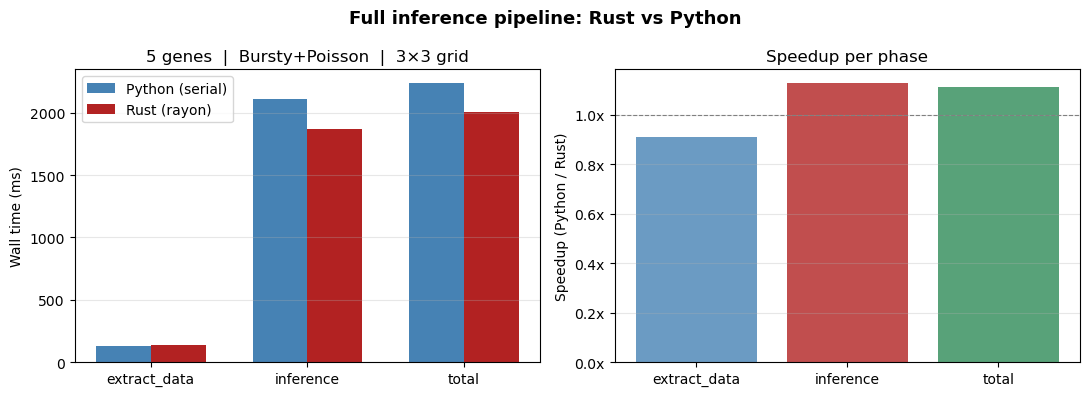

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

labels   = ['extract_data', 'inference', 'total']
py_vals  = [py_ext5, py_inf5, py_total5]
ru_vals  = [ru_ext5, ru_inf5, ru_total5]
x        = np.arange(len(labels))
w        = 0.35

ax = axes[0]
ax.bar(x - w/2, py_vals, w, color='steelblue',  label='Python (serial)')
ax.bar(x + w/2, ru_vals, w, color='firebrick',  label='Rust (rayon)')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('Wall time (ms)')
ax.set_title(f'{len(BENCH_GENES)} genes  |  {BENCH_MODEL.bio_model}+{BENCH_MODEL.seq_model}  |  3×3 grid')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1]
speedups5 = [p / r for p, r in zip(py_vals, ru_vals)]
ax.bar(labels, speedups5, color=['steelblue', 'firebrick', 'seagreen'], alpha=0.8)
ax.axhline(1, color='grey', lw=0.8, ls='--')
ax.set_ylabel('Speedup (Python / Rust)')
ax.set_title('Speedup per phase')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1fx'))
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Full inference pipeline: Rust vs Python', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

## Benchmark 6 — full inference pipeline

End-to-end timing from raw count matrices to biophysical parameters.

Model: **Bursty + Poisson**  |  5 genes  |  728 cells  |  3×3 = 9 grid points  |  15 iterations / restart

For this small analysis L-BFGS-B Python overhead dominates over raw computation; the
Rust speedup is primarily in `extract_data` (histogram extraction).  For larger analyses
(100+ genes, large grids), both the histogram and model-evaluation speedups compound.

In [21]:
header = f'{"Scenario":<58} {"Python (ms)":>12} {"Rust (ms)":>10} {"Speedup":>9}'
print(header)
print('-' * len(header))

all_rows = [
    ('Histogram  5k cells × 200 genes, max=20  [counting]',
     py_times[gene_counts.index(200)], ru_times[gene_counts.index(200)]),
    ('Histogram 20k cells × 100 genes, max=20  [counting]',
     py_times2[-1], ru_times2[-1]),
    ('Histogram  real data (gaba)  728 cells × 200 genes',
     py_times4[-1], ru_times4[-1]),
    ('PSS eval   Bursty+Poisson, grid (100×100)',
     py_pss[grid_sizes5.index(100)], ru_pss[grid_sizes5.index(100)]),
    ('PSS eval   Bursty+Poisson, grid (500×500)',
     py_pss[grid_sizes5.index(500)], ru_pss[grid_sizes5.index(500)]),
    ('Pipeline   extract_data  728 cells × 5 genes',
     py_ext5, ru_ext5),
    ('Pipeline   inference     728 cells × 5 genes, 3×3 grid',
     py_inf5, ru_inf5),
    ('Pipeline   total         728 cells × 5 genes, 3×3 grid',
     py_total5, ru_total5),
]
for label, py_t, ru_t in all_rows:
    print(f'{label:<58} {py_t:>12.1f} {ru_t:>10.1f} {py_t/ru_t:>8.1f}x')

Scenario                                                    Python (ms)  Rust (ms)   Speedup
--------------------------------------------------------------------------------------------
Histogram  5k cells × 200 genes, max=20  [counting]               407.9       44.8      9.1x
Histogram 20k cells × 100 genes, max=20  [counting]               892.6       24.1     37.0x
Histogram  real data (gaba)  728 cells × 200 genes                 43.6        2.4     18.4x
PSS eval   Bursty+Poisson, grid (100×100)                           2.9        0.6      4.5x
PSS eval   Bursty+Poisson, grid (500×500)                          69.1        7.0      9.9x
Pipeline   extract_data  728 cells × 5 genes                      127.1      139.6      0.9x
Pipeline   inference     728 cells × 5 genes, 3×3 grid           2108.8     1869.6      1.1x
Pipeline   total         728 cells × 5 genes, 3×3 grid           2235.8     2009.2      1.1x
